In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/OASIS/Twitter_Data.csv'
df = pd.read_csv(file_path)

df.head(), df.shape

(                                          clean_text  category
 0  when modi promised “minimum government maximum...      -1.0
 1  talk all the nonsense and continue all the dra...       0.0
 2  what did just say vote for modi  welcome bjp t...       1.0
 3  asking his supporters prefix chowkidar their n...       1.0
 4  answer who among these the most powerful world...       1.0,
 (162980, 2))

In [3]:
# Remove rows with missing labels
df = df.dropna(subset=['category'])

# Convert labels to int
df['category'] = df['category'].astype(int)

df['category'].value_counts()

,count
category,
1,72250
0,55213
-1,35510


In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower() # Convert to string to handle non-string types (e.g., NaNs)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['processed_text'] = df['clean_text'].apply(preprocess_text)
df[['clean_text', 'processed_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_text,processed_text
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,asking supporter prefix chowkidar name modi gr...
4,answer who among these the most powerful world...,answer among powerful world leader today trump...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),   # big improvement
    min_df=5
)

X = vectorizer.fit_transform(df['processed_text'])
y = df['category']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8737229636447308

Classification Report:

              precision    recall  f1-score   support

          -1       0.81      0.83      0.82      7230
           0       0.85      0.95      0.90     10961
           1       0.94      0.83      0.88     14404

    accuracy                           0.87     32595
   macro avg       0.86      0.87      0.87     32595
weighted avg       0.88      0.87      0.87     32595



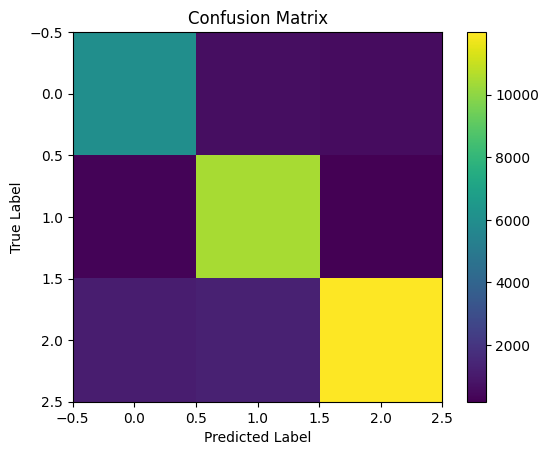

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

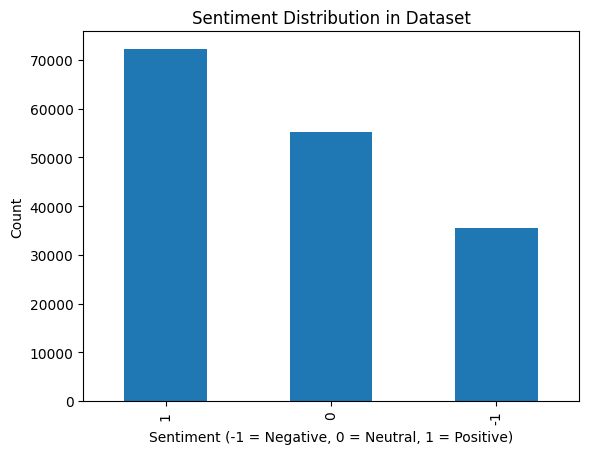

In [11]:
df['category'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution in Dataset")
plt.xlabel("Sentiment (-1 = Negative, 0 = Neutral, 1 = Positive)")
plt.ylabel("Count")
plt.show()